# Simple Polynomial Regression

### Creating and visualizing dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
x = 6 * np.random.rand(200, 1) - 3
y = 0.8 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2

In [8]:
x[:4], x.shape

(array([[-0.87814973],
        [ 1.15443982],
        [ 2.34327273],
        [ 1.75383824]]),
 (200, 1))

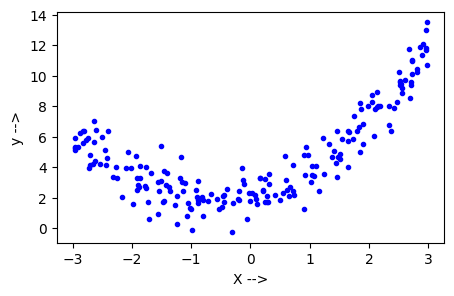

In [9]:
plt.figure(figsize=(5,3))
plt.plot(x, y, 'b.')
plt.xlabel('X -->')
plt.ylabel('y -->')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=11)

In [22]:
x_train.shape, x_test.shape

((160, 1), (40, 1))

### Training model

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lin_reg = LinearRegression()

In [25]:
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Testing and visualizing our model's solution

In [26]:
y_pred = lin_reg.predict(x_test)

In [27]:
from sklearn.metrics import r2_score

In [28]:
r2_score(y_test, y_pred)

0.4298346158924009

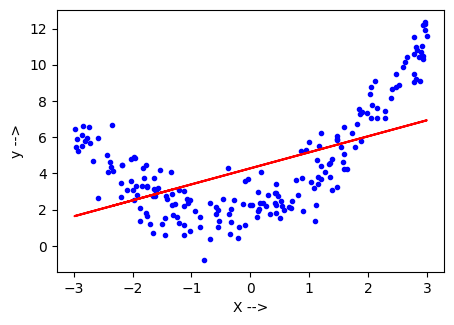

In [30]:
plt.figure(figsize=(5,3.4))
plt.plot(x, y, 'b.')
plt.plot(x_train, lin_reg.predict(x_train), color='r')
plt.xlabel('X -->')
plt.ylabel('y -->')
plt.show()

### Applying **Polynomial Regression** with degree=2

In [58]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [57]:
poly = PolynomialFeatures(degree=2)  # include_bias=True by default

In [70]:
x_train_trans = poly.fit_transform(x_train)
x_test_trans = poly.transform(x_test)

In [43]:
print(x_train[0])
print( x_train_trans[0])

[-1.34321817]
[ 1.         -1.34321817  1.80423505]


### Train model after applying polynomial features

In [35]:
pol_reg = LinearRegression()

In [36]:
pol_reg.fit(x_train_trans, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Testing our model

In [37]:
y_pred1 = pol_reg.predict(x_test_trans)

In [38]:
r2_score(y_test, y_pred1)

0.929314842298126

In [41]:
print(pol_reg.coef_)
print(pol_reg.intercept_)

[[0.         0.8946827  0.78331524]]
[2.01506926]


#### Visualizing our model

In [46]:
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
x_new_trans = poly.transform(x_new)
y_new = pol_reg.predict(x_new_trans)

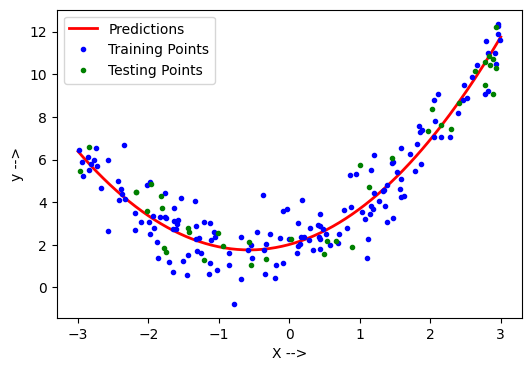

In [56]:
plt.figure(figsize=(6, 4))
plt.plot(x_new, y_new, 'r-', linewidth=2, label='Predictions')
plt.plot(x_train, y_train, 'b.', label='Training Points')
plt.plot(x_test, y_test, 'g.', label='Testing Points')
plt.xlabel('X -->')
plt.ylabel('y -->')
plt.legend()
plt.show()

### Creating function for Polynomial Regression

In [59]:
from sklearn.pipeline import Pipeline

In [86]:
def Polynomial_Regression(degree):
    x_new = np.linspace(-3, 3, 100).reshape(100, 1)
    x_new_trans = poly.transform(x_new)

    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lr = LinearRegression()
    polynomial_reg = Pipeline([
        ('poly_features', poly_features),
        ('std_scaler', std_scaler),
        ('lin_reg', lr)
    ])
    polynomial_reg.fit(x, y)
    y_new = polynomial_reg.predict(x_new)

    plt.figure(figsize=(6,4.3))
    plt.plot(x_new, y_new, 'r', linewidth=2, label='Degree '+str(degree))
    plt.plot(x_train, y_train, 'b.')
    plt.plot(x_test, y_test, 'g.')
    plt.xlabel('X -->')
    plt.ylabel('y -->')
    plt.legend()
    plt.axis([-3, 3, 0, 10])
    plt.show()

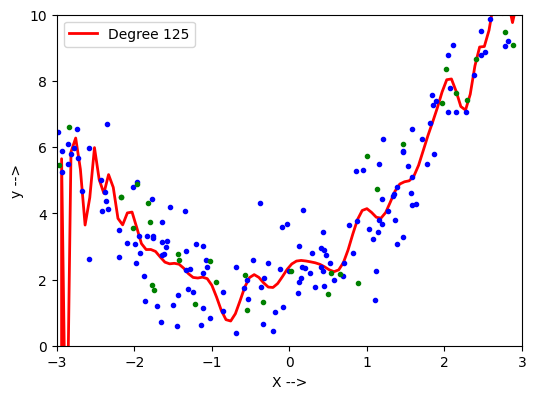

In [87]:
Polynomial_Regression(125)